# Preprocessing — AE v5

In [1]:
import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

DATA_DIR  = '../../../data/new'
MODEL_DIR = '../../../model/03_ae'
os.makedirs(MODEL_DIR, exist_ok=True)

FEATURE_COLS = ['nominal', 'kategori_detail_encoded', 'hour_sin', 'hour_cos', 'nominal_z_user_kat']
SCALED_COLS  = [f'{c}_scaled' for c in FEATURE_COLS]

## Load & Split

In [2]:
df = pd.read_csv(f'{DATA_DIR}/df_transaksi.csv', parse_dates=['timestamp'])

df_debit = (
    df[(df['tipe_mutasi'] == 'Debit') & df['kategori_detail_encoded'].notna()]
    .copy()
)
df_debit['kategori_detail_encoded'] = df_debit['kategori_detail_encoded'].astype(float)

df_train     = df_debit[df_debit['phase'] == 'train'].copy()
df_threshold = df_debit[df_debit['phase'] == 'threshold'].copy()
df_test      = df_debit[df_debit['phase'] == 'test'].copy()

print(f"train     : {len(df_train):,}")
print(f"threshold : {len(df_threshold):,}")
print(f"test      : {len(df_test):,}  (anomali: {int(df_test['label_anomali'].sum())})")
# nominal_z_user_kat: z-score per (user, kategori) — stats fit on train only
# ddof=0 agar grup 1 sampel menghasilkan std=0 (bukan NaN)
df_train['nominal_z_user_kat'] = (
    df_train.groupby(['id_user', 'kategori_detail'])['nominal']
    .transform(lambda x: (x - x.mean()) / (x.std(ddof=0) + 1e-9))
)

_z_stats = (
    df_train.groupby(['id_user', 'kategori_detail'])['nominal']
    .agg(z_mean='mean', z_std=lambda x: x.std(ddof=0))
    .reset_index()
)

for _df in [df_threshold, df_test]:
    _tmp = _df[['id_user', 'kategori_detail', 'nominal']].merge(
        _z_stats, on=['id_user', 'kategori_detail'], how='left'
    )
    # Combo tidak ada di train → z-score 0 (netral)
    _df['nominal_z_user_kat'] = np.where(
        _tmp['z_mean'].notna(),
        (_tmp['nominal'] - _tmp['z_mean']) / (_tmp['z_std'].fillna(0) + 1e-9),
        0.0
    )


train     : 176,459
threshold : 45,110
test      : 44,315  (anomali: 1329)


## Scale

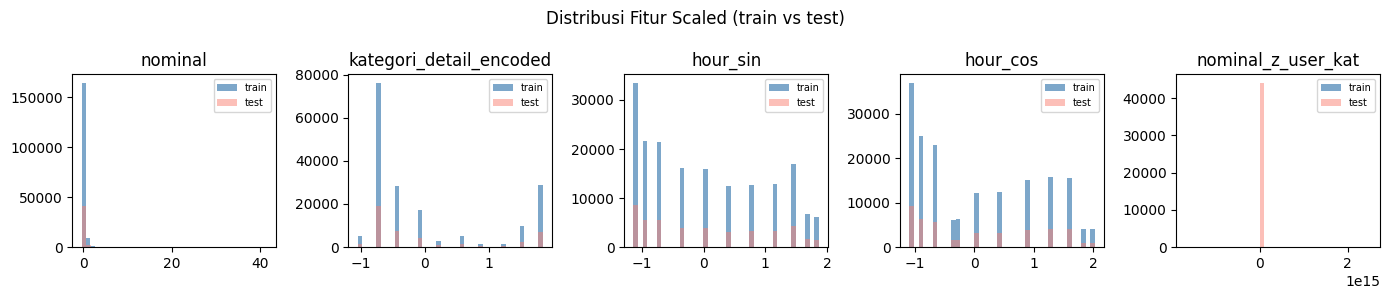

In [3]:
scaler = StandardScaler()
scaler.fit(df_train[FEATURE_COLS])

for df_phase in [df_train, df_threshold, df_test]:
    scaled = scaler.transform(df_phase[FEATURE_COLS])
    for i, col in enumerate(FEATURE_COLS):
        df_phase[f'{col}_scaled'] = scaled[:, i]

fig, axes = plt.subplots(1, len(FEATURE_COLS), figsize=(14, 3))
for ax, col in zip(axes, SCALED_COLS):
    ax.hist(df_train[col], bins=40, alpha=0.7, color='steelblue', label='train')
    ax.hist(df_test[col],  bins=40, alpha=0.5, color='salmon',    label='test')
    ax.set_title(col.replace('_scaled', ''))
    ax.legend(fontsize=7)
plt.suptitle('Distribusi Fitur Scaled (train vs test)')
plt.tight_layout()
plt.show()

## Save

In [4]:
KEEP_COLS = (
    ['id_transaksi', 'id_user', 'timestamp', 'kategori_detail', 'nominal', 'label_anomali', 'phase']
    + FEATURE_COLS + SCALED_COLS
)

df_train[KEEP_COLS].to_csv(f'{DATA_DIR}/pre_train.csv', index=False)
df_threshold[KEEP_COLS].to_csv(f'{DATA_DIR}/pre_threshold.csv', index=False)
df_test[KEEP_COLS].to_csv(f'{DATA_DIR}/pre_test.csv', index=False)

joblib.dump({'scaler': scaler, 'feature_cols': FEATURE_COLS, 'scaled_cols': SCALED_COLS, 'z_stats': _z_stats},
            f'{MODEL_DIR}/preprocessing_meta.pkl')

print(f"pre_train.csv     → {len(df_train):,} rows")
print(f"pre_threshold.csv → {len(df_threshold):,} rows")
print(f"pre_test.csv      → {len(df_test):,} rows")
print(f"preprocessing_meta.pkl saved")

pre_train.csv     → 176,459 rows
pre_threshold.csv → 45,110 rows
pre_test.csv      → 44,315 rows
preprocessing_meta.pkl saved
